In [1]:
import numpy as np
import pandas as pd
import sys
import os
sys.path.append(os.path.abspath('..'))
from models import timoshenko_model as model
import matplotlib.pyplot as plt
from scripts import nodes as n
from scripts import elements as e
from minimal_models import material_params as mat
from scipy.linalg import eigh
import plotly.graph_objects as go

In [2]:
n1 = n.nodes(0, 0, 0)
n2 = n.nodes(5, 5, 0)
n3 = n.nodes(10, 10, 0)
n4 = n.nodes(15, 15, 0)
n5 = n.nodes(20, 20, 0)
n6 = n.nodes(25, 25, 0)
n7 = n.nodes(30, 30, 0)
n8 = n.nodes(35, 35, 0)
n9 = n.nodes(40, 40, 0)
n10 = n.nodes(45, 45, 0)
n11 = n.nodes(50, 50, 0)
n12 = n.nodes(55, 55, 0)
n13 = n.nodes(60, 60, 0)
n14 = n.nodes(65, 65, 0)
n15 = n.nodes(70, 70, 0)
n16 = n.nodes(75, 75, 0)
n17 = n.nodes(80, 80, 0)
n18 = n.nodes(85, 85, 0)
n19 = n.nodes(90, 90, 0)
n20 = n.nodes(95, 95, 0)
n21 = n.nodes(100, 100, 0)
n22 = n.nodes(105, 105, 0)
n23 = n.nodes(110, 110, 0)
n24 = n.nodes(115, 115, 0)
n25 = n.nodes(120, 120, 0)
n26 = n.nodes(125, 125, 0)
n27 = n.nodes(130, 130, 0)
n28 = n.nodes(135, 135, 0)
n29 = n.nodes(140, 140, 0)
n30 = n.nodes(145, 145, 0)
n31 = n.nodes(150, 150, 0)
n32 = n.nodes(155, 155, 0)
n33 = n.nodes(160, 160, 0)
n34 = n.nodes(165, 165, 0)
n35 = n.nodes(170, 170, 0)


nodes = [n1, n2, n3, n4, n5, n6, n7, n8, n9, n10, n11, n12, n13, n14, n15, n16, n17, n18, n19, n20,
          n21, n22, n23, n24, n25, n26, n27, n28, n29, n30, n31, n32, n33, n34, n35]

In [3]:
# define element parameters
E=210e9 #Pa
nu = 0.3 #Poisson's ratio
G = E/(2*(1+nu)) #Pa
rho=7850 #kg/m3
d1 = 0.8 #m
d2 = 1.8 #m
t1 = 0.03 #m
t2 = 0.08   #0.1125 #m
L_truss_element_y = 15 #m
h_truss = 18 #m
Aeq, Ieqy, Ieqz, b_eq = mat.effective_truss_stiffness(d1, d2, t1, t2, L_truss_element_y, h_truss) 
It = (b_eq * h_truss**3 / 3) * (1 - 0.63 * (h_truss / b_eq) * (1 - (h_truss**4 / (12 * b_eq**4))))
k = 5/6
Ip  = Ieqy + Ieqz
ep_K = [E, G, Aeq, Ieqy, Ieqz, It, k]
ep_m = [rho, Aeq, Ieqy, Ieqz, Ip]
print("Effective area: ", Aeq)
print("Effective moment of inertia about y-axis: ", Ieqy)
print("Effective moment of inertia about z-axis: ", Ieqz)
print("Effective torsional constant: ", It)


Effective area:  3.1704953060028203
Effective moment of inertia about y-axis:  178.54105746243093
Effective moment of inertia about z-axis:  93.22042753917786
Effective torsional constant:  200354732285.9182


In [4]:
e1 = e.elements(n1, n2, ep_K, ep_m)
e2 = e.elements(n2, n3, ep_K, ep_m)
e3 = e.elements(n3, n4, ep_K, ep_m)
e4 = e.elements(n4, n5, ep_K, ep_m)
e5 = e.elements(n5, n6, ep_K, ep_m)
e6 = e.elements(n6, n7, ep_K, ep_m)
e7 = e.elements(n7, n8, ep_K, ep_m)
e8 = e.elements(n8, n9, ep_K, ep_m)
e9 = e.elements(n9, n10, ep_K, ep_m)
e10 = e.elements(n10, n11, ep_K, ep_m)
e11 = e.elements(n11, n12, ep_K, ep_m)
e12 = e.elements(n12, n13, ep_K, ep_m)
e13 = e.elements(n13, n14, ep_K, ep_m)
e14 = e.elements(n14, n15, ep_K, ep_m)
e15 = e.elements(n15, n16, ep_K, ep_m)
e16 = e.elements(n16, n17, ep_K, ep_m)
e17 = e.elements(n17, n18, ep_K, ep_m)
e18 = e.elements(n18, n19, ep_K, ep_m)
e19 = e.elements(n19, n20, ep_K, ep_m)
e20 = e.elements(n20, n21, ep_K, ep_m)
e21 = e.elements(n21, n22, ep_K, ep_m)
e22 = e.elements(n22, n23, ep_K, ep_m)
e23 = e.elements(n23, n24, ep_K, ep_m)
e24 = e.elements(n24, n25, ep_K, ep_m)
e25 = e.elements(n25, n26, ep_K, ep_m)
e26 = e.elements(n26, n27, ep_K, ep_m)
e27 = e.elements(n27, n28, ep_K, ep_m)
e28 = e.elements(n28, n29, ep_K, ep_m)
e29 = e.elements(n29, n30, ep_K, ep_m)
e30 = e.elements(n30, n31, ep_K, ep_m)
e31 = e.elements(n31, n32, ep_K, ep_m)
e32 = e.elements(n32, n33, ep_K, ep_m)
e33 = e.elements(n33, n34, ep_K, ep_m)
e34 = e.elements(n34, n35, ep_K, ep_m)


elements = [e1, e2, e3, e4, e5, e6, e7, e8, e9, e10, e11, e12, e13, e14, e15, e16, e17, e18,
             e19, e20, e21, e22, e23, e24, e25, e26, e27, e28, e29, e30, e31, e32, e33, e34]

element_nodes = [(1, 2), (2, 3), (3, 4), (4, 5), (5, 6), (6, 7), (7, 8), (8, 9), (9, 10), (10, 11),
                 (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17), (17, 18), (18, 19), (19, 20), (20, 21),
                 (21, 22), (22, 23), (23, 24), (24, 25), (25, 26), (26, 27), (27, 28), (28, 29), (29, 30), (30, 31), 
                 (31, 32), (32, 33), (33, 34), (34, 35)]

dofs = n.degrees_of_freedom(nodes)

element_locs = []

for (nA, nB) in element_nodes:
    dofs_A = dofs[f'dof_{nA}']
    dofs_B = dofs[f'dof_{nB}']
    element_locs.append(np.hstack((dofs_A, dofs_B)))


In [5]:
N = len(nodes)
DOFS_per_node = 6



K_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))
M_global = np.zeros((N * DOFS_per_node, N * DOFS_per_node))

K_locs = []
M_locs = []



for i in range(len(element_locs)):
    K_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-1]
    M_global[np.ix_(element_locs[i], element_locs[i])] += elements[i][-2]



# To restore symmetry of the global stiffness and mass matrices
K_global = 0.5 * (K_global + K_global.T)
M_global = 0.5 * (M_global + M_global.T)



In [6]:
indices_to_remove = np.hstack((dofs['dof_1'][0:3], dofs['dof_35'][0:3]))
keep_indices = np.setdiff1d(np.arange(N * DOFS_per_node), indices_to_remove)
K_global_reduced = K_global[np.ix_(keep_indices, keep_indices)]
M_global_reduced = M_global[np.ix_(keep_indices, keep_indices)]

In [7]:
eigvals_global, eigvecs_global = eigh(K_global_reduced, M_global_reduced)


tol = 1e-6
positive = eigvals_global > tol
eigvals_global = eigvals_global[positive]
eigvecs_global = eigvecs_global[:, positive]

frequencies_rad = np.sqrt(eigvals_global)
frequencies_hz = frequencies_rad / (2 * np.pi)


data_freqs = pd.DataFrame({
    'Frequency (Hz)': frequencies_hz,
    'Frequency (rad/s)': frequencies_rad
})

display(data_freqs[:10])

,Frequency (Hz),Frequency (rad/s)
0,0.039339,0.247177
1,0.754420,4.740163
2,1.034361,6.499084
3,2.928360,18.399430
4,3.912450,24.582646
5,6.282614,39.474825
6,8.081722,50.778956
7,10.495376,65.944390
8,10.760572,67.610669
9,12.909875,81.115135


In [8]:
eigvecs_full = e.expand_eigenvectors(eigvecs_global, keep_indices, N*DOFS_per_node)
print("Expanded eigenvectors shape:", eigvecs_full.shape)

Expanded eigenvectors shape: (210, 204)


In [9]:
eigvecs_disp_full = e.extract_displacement(eigvecs_full, keep=3, skip=3)
eigvecs_full.shape


(210, 204)

In [10]:
# Extract rotations the same way you did for displacements
eigvecs_rot_full = e.extract_rotation(eigvecs_full, keep=3, skip=3)
print(eigvecs_rot_full.shape)  # (n_nodes*3, n_modes)

(105, 204)


In [11]:
#First ten modes
modes_to_plot = 15
modes = []
for i in range(modes_to_plot):
    modes.append(eigvecs_disp_full[:, i].reshape(-1, 3) + nodes)


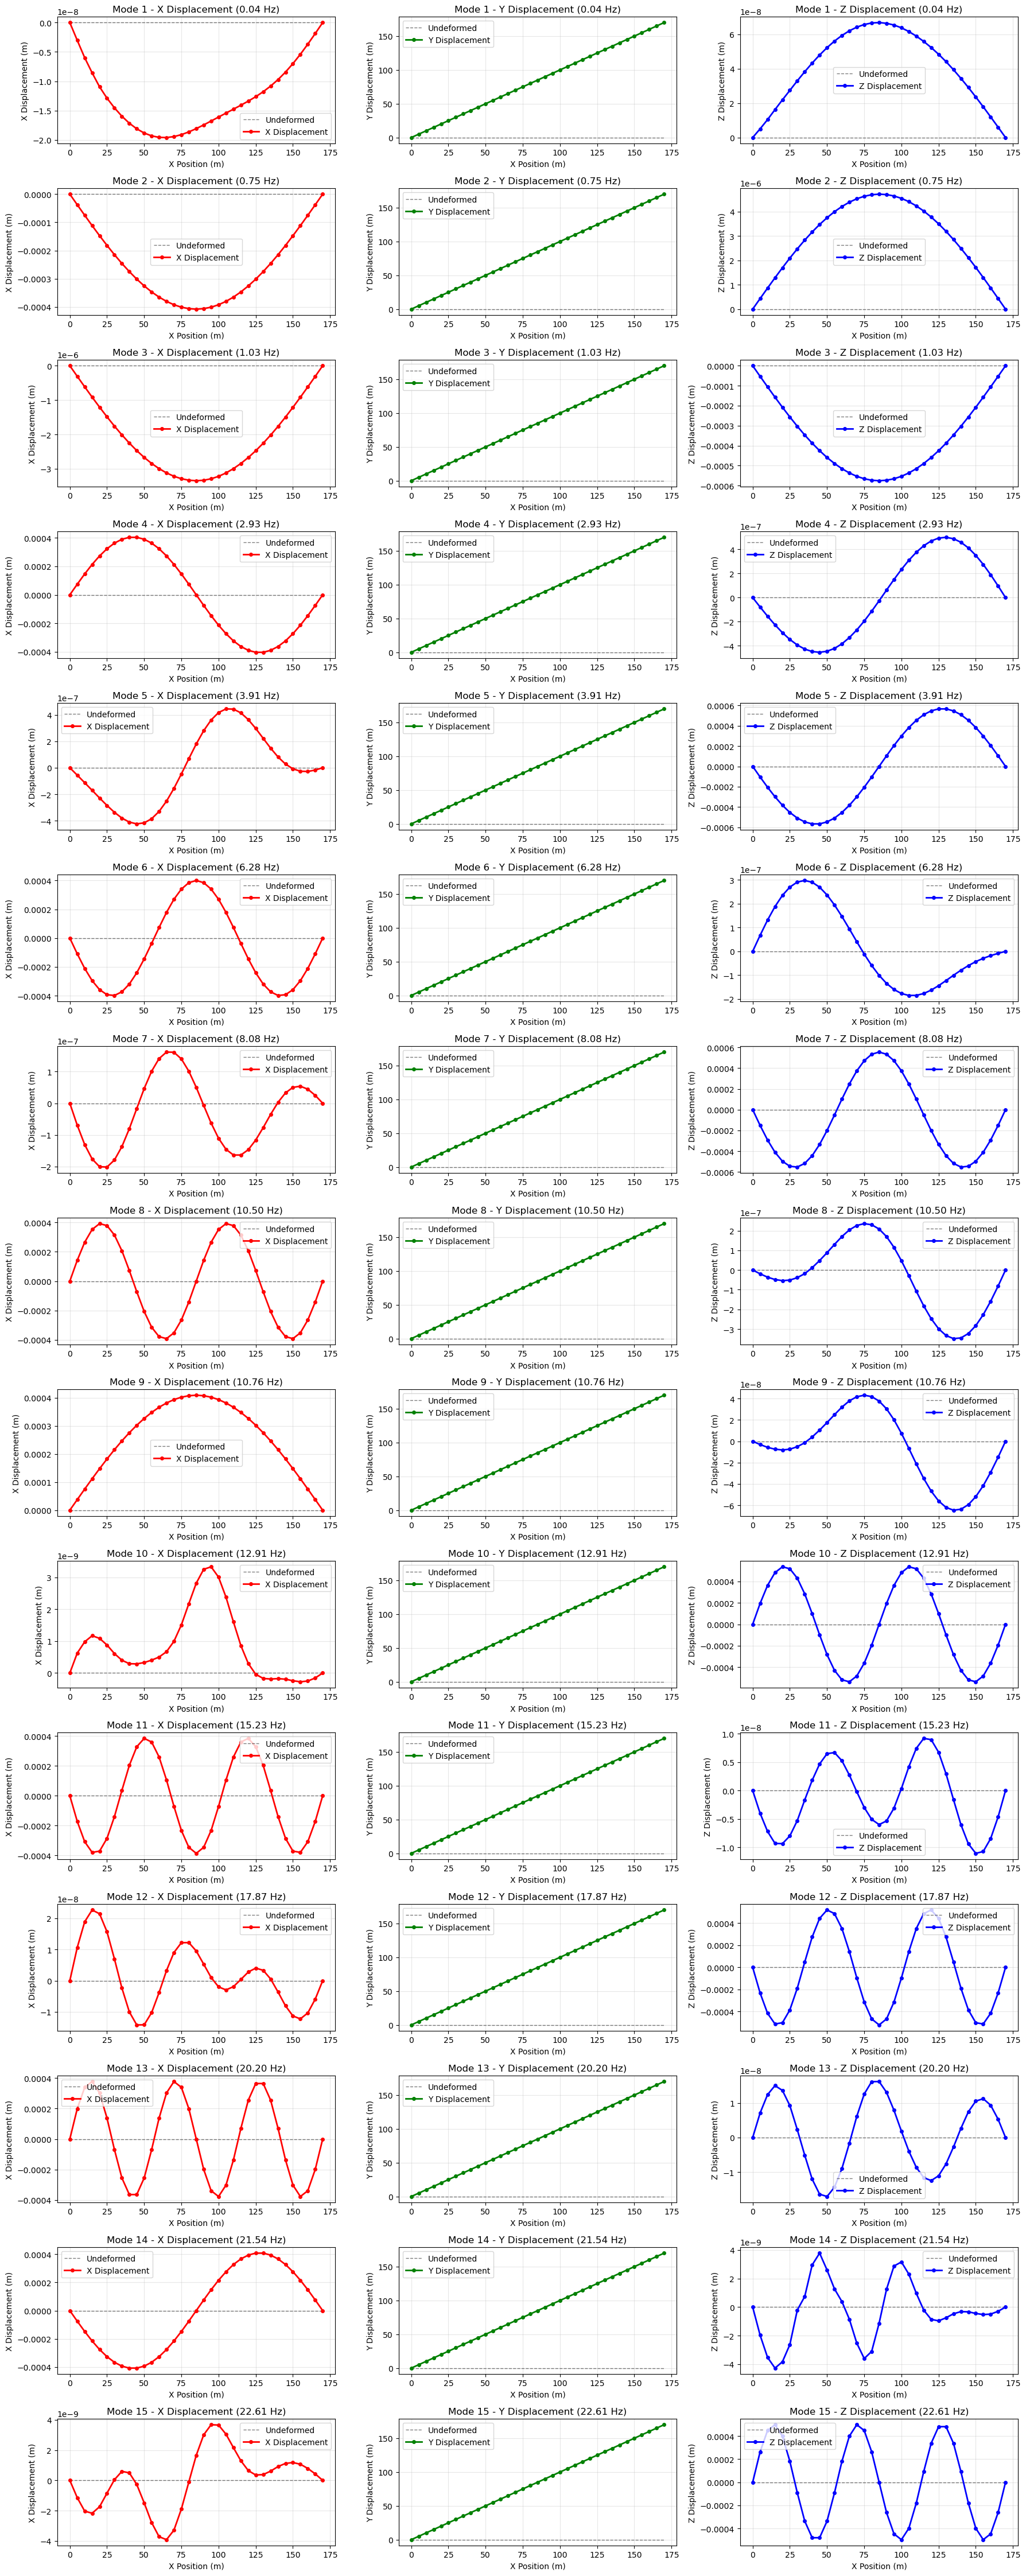

In [12]:
fig, axes = plt.subplots(modes_to_plot, 3, figsize=(18, 3*modes_to_plot))

for i in range(modes_to_plot):
    # X displacement
    ax_x = axes[i, 0] if modes_to_plot > 1 else axes[0]
    x_undeformed = [node[0] for node in nodes]
    x_deformed = modes[i][:, 0]
    ax_x.plot(x_undeformed, [0]*len(nodes), 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_x.plot(x_undeformed, x_deformed - x_undeformed, 'r-', linewidth=2, label='X Displacement', marker='o', markersize=4)
    ax_x.set_xlabel('X Position (m)')
    ax_x.set_ylabel('X Displacement (m)')
    ax_x.set_title(f'Mode {i+1} - X Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_x.grid(True, alpha=0.3)
    ax_x.legend()
    
    # Y displacement
    ax_y = axes[i, 1] if modes_to_plot > 1 else axes[1]
    y_deformed = modes[i][:, 1]
    ax_y.plot(x_undeformed, [0]*len(nodes), 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_y.plot(x_undeformed, y_deformed, 'g-', linewidth=2, label='Y Displacement', marker='o', markersize=4)
    ax_y.set_xlabel('X Position (m)')
    ax_y.set_ylabel('Y Displacement (m)')
    ax_y.set_title(f'Mode {i+1} - Y Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_y.grid(True, alpha=0.3)
    ax_y.legend()
    
    # Z displacement
    ax_z = axes[i, 2] if modes_to_plot > 1 else axes[2]
    z_undeformed = [node[2] for node in nodes]
    z_deformed = modes[i][:, 2]
    ax_z.plot(x_undeformed, z_undeformed, 'k--', linewidth=1, label='Undeformed', alpha=0.5)
    ax_z.plot(x_undeformed, z_deformed, 'b-', linewidth=2, label='Z Displacement', marker='o', markersize=4)
    ax_z.set_xlabel('X Position (m)')
    ax_z.set_ylabel('Z Displacement (m)')
    ax_z.set_title(f'Mode {i+1} - Z Displacement ({frequencies_hz[i]:.2f} Hz)')
    ax_z.grid(True, alpha=0.3)
    ax_z.legend()

plt.tight_layout()
plt.show()

In [13]:
for i in range(modes_to_plot):
    line_x = []
    line_y = []
    line_z = []
    for nA, nB in element_nodes:
        p1 = modes[i][nA - 1]
        p2 = modes[i][nB - 1]
        line_x.extend([p1[0], p2[0], None])
        line_y.extend([p1[1], p2[1], None])
        line_z.extend([p1[2], p2[2], None])

    fig_lines = go.Figure(
        data=[
            go.Scatter3d(
                x=line_x,
                y=line_y,
                z=line_z,
                mode='lines',
                line=dict(color='black', width=2)
            ),
            go.Scatter3d(
                x=modes[i][:, 0],
                y=modes[i][:, 1],
                z=modes[i][:, 2],
                mode='markers',
                marker=dict(size=3, color='blue')
            )
        ]
    )

    fig_lines.update_layout(
        title=f'Mode {i+1} - Deformed Configuration (Elements)',
        scene=dict(
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)'
        ),
        width=900,
        height=700
    )

    fig_lines.show()

In [14]:
modes_rot = []
for i in range(modes_to_plot):
    # each node has 3 rotation components θx, θy, θz
    # reshape into (n_nodes, 3)
    modes_rot.append(eigvecs_rot_full[:, i].reshape(-1, 3))

In [15]:
import numpy as np
import plotly.graph_objects as go

scale = 5      # exaggerate rotation for visualization
radius = 0.05  # cross-section radius for display

for i in range(modes_to_plot):
    # Deformed node positions
    deformed_nodes = eigvecs_disp_full[:, i].reshape(-1, 3) + nodes

    # Torsional rotations (around local x-axis)
    rotations = modes_rot[i][:, 0]  # θx for each node

    line_x = []
    line_y = []
    line_z = []

    for nA, nB in element_nodes:
        p1 = deformed_nodes[nA - 1]
        p2 = deformed_nodes[nB - 1]

        line_x.extend([p1[0], p2[0], None])
        line_y.extend([p1[1], p2[1], None])
        line_z.extend([p1[2], p2[2], None])

    fig_lines = go.Figure(
        data=[
            # Beam elements
            go.Scatter3d(
                x=line_x,
                y=line_y,
                z=line_z,
                mode='lines',
                line=dict(color='black', width=2)
            ),
            # Nodes
            go.Scatter3d(
                x=deformed_nodes[:, 0],
                y=deformed_nodes[:, 1],
                z=deformed_nodes[:, 2],
                mode='markers',
                marker=dict(size=3, color='blue')
            )
        ]
    )

    # Add small rotated circles at nodes to visualize torsion
    t = np.linspace(0, 2*np.pi, 30)
    for j, node in enumerate(deformed_nodes):
        theta = rotations[j] * scale
        circ_y = node[1] + radius*np.cos(t)*np.cos(theta)
        circ_z = node[2] + radius*np.cos(t)*np.sin(theta)
        circ_x = np.full_like(t, node[0])

        fig_lines.add_trace(go.Scatter3d(
            x=circ_x,
            y=circ_y,
            z=circ_z,
            mode='lines',
            line=dict(color='red', width=2)
        ))

    fig_lines.update_layout(
        title=f'Mode {i+1} - Torsional Deformed Configuration',
        scene=dict(
            xaxis_title='X (m)',
            yaxis_title='Y (m)',
            zaxis_title='Z (m)'
        ),
        width=900,
        height=700
    )

    fig_lines.show()